Q3: Risk-Sensitive Robot Navigation Near Hazards

Environment Defined

In [1]:
import numpy as np
GRID_SIZE = 10
GAMMA = 0.9

STEP_REWARD = -1
GOAL_REWARD = 50
FAILURE_REWARD = -200

GOAL = (8, 1)
FAILURE_STATE = "FAILURE"

ACTIONS = ["Up", "Down", "Left", "Right"]

HAZARD_CELLS = {
    (3,0),(3,1),(3,2),(3,3),(3,4),
    (4,0),(4,1),(4,2),(4,3),(4,4),
    (5,0),(5,1),(5,2),(5,3),(5,4),
}



def compute_h(x, y):
    return min(abs(x - hx) + abs(y - hy) for (hx, hy) in HAZARD_CELLS)          #manhattan distance



def slip_probability(h):                        #we can see slip prob depends on the proximity

    if h >= 4:
        return 0.05
    elif h == 3:
        return 0.1
    elif h == 2:
        return 0.2
    elif h == 1:
        return 0.3
    else:                          #(inside hazard)
        return 0.7



states = []

for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        h = compute_h(x, y)
        states.append((x, y, h))

states.append(FAILURE_STATE)

terminal_states = {FAILURE_STATE}


for state in states:
    if state != FAILURE_STATE:
        if (state[0], state[1]) == GOAL:
            terminal_states.add(state)



def get_transitions(state, action):
    if state in terminal_states:
        return []

    x, y, h = state

    def valid_cell(a, b):
        return 0 <= a < GRID_SIZE and 0 <= b < GRID_SIZE

    p_slip = slip_probability(h)


    if action == "Up":
        nx, ny = x, y+1
        slip_cells = [(x-1,y), (x+1,y)]

    elif action == "Down":
        nx, ny = x, y-1
        slip_cells = [(x-1,y), (x+1,y)]

    elif action == "Left":
        nx, ny = x-1, y
        slip_cells = [(x,y+1), (x,y-1)]

    elif action == "Right":
        nx, ny = x+1, y
        slip_cells = [(x,y+1), (x,y-1)]

    transitions = []


    # Intended Move
    if valid_cell(nx, ny):
        next_h = compute_h(nx, ny)

        if h <= 1:                  # If very close to hazard -> catastrophic risk
            transitions.append(
                (1 - p_slip,
                 (nx, ny, next_h),
                 GOAL_REWARD if (nx, ny) == GOAL else STEP_REWARD)
            )

            transitions.append(
                (p_slip,
                 FAILURE_STATE,
                 FAILURE_REWARD)
            )

            return transitions

        else:
            transitions.append(
                (1 - p_slip,
                 (nx, ny, next_h),
                 GOAL_REWARD if (nx, ny) == GOAL else STEP_REWARD)
            )

    else:
        transitions.append(                     # Hit boundary -> stay in place
            (1 - p_slip,
             (x, y, h),
             STEP_REWARD)
        )

        if h <= 1:
            transitions.append(
                (p_slip,
                 FAILURE_STATE,
                 FAILURE_REWARD)
            )
            return transitions


    # Slip Moves (only if not catastrophic zone)
    if h > 1:

        for sx, sy in slip_cells:

            if valid_cell(sx, sy):
                next_h = compute_h(sx, sy)
                reward = GOAL_REWARD if (sx, sy) == GOAL else STEP_REWARD
                transitions.append(
                    (p_slip / 2,
                     (sx, sy, next_h),
                     reward)
                )
            else:
                transitions.append(
                    (p_slip / 2,
                     (x, y, h),
                     STEP_REWARD)
                )

    return transitions


Value Iteration

In [2]:
def run_value_iteration(states, terminal_states,
                        tol=1e-6, max_iters=1000):

    V = {s: 0.0 for s in states}

    iterations = 0

    for k in range(max_iters):

        delta = 0
        V_new = V.copy()

        for s in states:

            if s in terminal_states:
                continue                # V(terminal) = 0

            best_val = -float("inf")

            for a in ACTIONS:

                val = 0.0
                transitions = get_transitions(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            V_new[s] = best_val
            delta = max(delta, abs(best_val - V[s]))

        V = V_new
        iterations += 1

        if delta < tol:
            break


    # Extracting Optimal Policy
    policy = {}

    for s in states:

        if s in terminal_states:
            policy[s] = None
            continue

        best_action = None
        best_val = -float("inf")

        for a in ACTIONS:

            val = 0.0
            transitions = get_transitions(s, a)

            for p, s_next, r in transitions:
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        policy[s] = best_action

    return V, policy, iterations



# Run Value Iteration
V, policy, iters = run_value_iteration(states, terminal_states)

print("Value Iteration converged in:", iters, "iterations")


Value Iteration converged in: 46 iterations


Visualising Policies using arrows

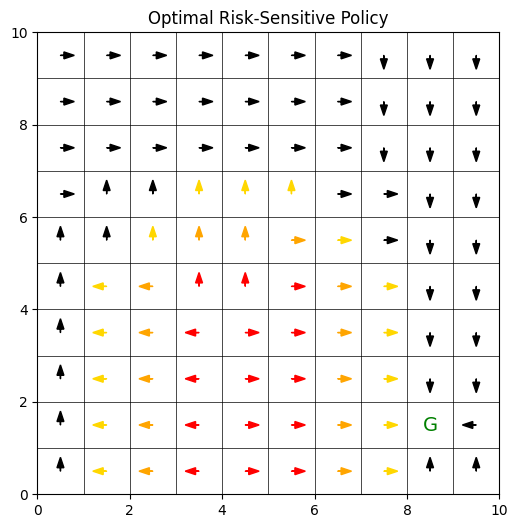

In [3]:
import matplotlib.pyplot as plt

def visualize_policy(policy, title="Optimal Policy"):

    plt.figure(figsize=(6,6))

    for i in range(GRID_SIZE+1):
        plt.plot([0, GRID_SIZE], [i, i], color='black', linewidth=0.5)
        plt.plot([i, i], [0, GRID_SIZE], color='black', linewidth=0.5)



    for x in range(GRID_SIZE):                              # Draw Policy
        for y in range(GRID_SIZE):

            h = compute_h(x, y)
            state = (x, y, h)

            if state in terminal_states:
                continue

            if state not in policy:
                continue

            action = policy[state]

            if action is None:
                continue

            # Arrow symbols
            if action == "Up":
                dx, dy = 0, 0.3
            elif action == "Down":
                dx, dy = 0, -0.3
            elif action == "Left":
                dx, dy = -0.3, 0
            elif action == "Right":
                dx, dy = 0.3, 0


            if (x, y) in HAZARD_CELLS:              # Color coding by risk proximity
                color = "red"
            elif h == 1:
                color = "orange"
            elif h == 2:
                color = "gold"
            else:
                color = "black"

            plt.arrow(x+0.5, y+0.5,
                      dx, dy,
                      head_width=0.15,
                      length_includes_head=True,
                      color=color)


    gx, gy = GOAL
    plt.text(gx+0.5, gy+0.5, "G",
             ha='center', va='center',
             fontsize=14, color='green')


    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.show()


visualize_policy(policy, title="Optimal Risk-Sensitive Policy")


Policy Iteration

In [4]:
def run_policy_iteration(states, terminal_states,
                         tol=1e-6,
                         max_policy_eval_iters=1000,
                         max_policy_iters=100):

    V = {s: 0.0 for s in states}


    policy = {}

    for s in states:
        if s in terminal_states:
            policy[s] = None
        else:
            policy[s] = np.random.choice(ACTIONS)

    policy_stable = False
    policy_iterations = 0


    while not policy_stable and policy_iterations < max_policy_iters:

        #Policy Evaluation
        for _ in range(max_policy_eval_iters):

            delta = 0

            for s in states:

                if s in terminal_states:
                    continue

                v_old = V[s]
                a = policy[s]

                val = 0.0
                transitions = get_transitions(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                V[s] = val
                delta = max(delta, abs(v_old - val))

            if delta < tol:
                break

        # Policy Improvement
        policy_stable = True

        for s in states:

            if s in terminal_states:
                continue

            old_action = policy[s]

            best_action = None
            best_value = -float("inf")

            for a in ACTIONS:

                val = 0.0
                transitions = get_transitions(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                if val > best_value:
                    best_value = val
                    best_action = a

            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        policy_iterations += 1

    return V, policy, policy_iterations

V_pi, policy_pi, pi_iters = run_policy_iteration(states, terminal_states)

print("Policy Iteration converged in:", pi_iters, "policy improvement steps")


Policy Iteration converged in: 7 policy improvement steps


## SARSA


In [5]:
import random
import numpy as np
import time
import tracemalloc


def sample_transition(state, action):
    transitions = get_transitions(state, action)
    probs = np.array([t[0] for t in transitions], dtype=float)
    probs = probs / probs.sum()
    choice = np.random.choice(len(transitions), p=probs)
    _, next_state, reward = transitions[choice]
    return next_state, reward



def epsilon_greedy_risk(Q, state, epsilon):
    if random.random() < epsilon:
        return random.choice(ACTIONS)

    return max(ACTIONS, key=lambda a: Q[(state, a)])



def run_sarsa_risk(states, terminal_states, ACTIONS, GAMMA, get_transitions,
                   episodes=5000, alpha=0.1, epsilon=0.1, max_steps=200):

    Q = {(s, a): 0.0 for s in states for a in ACTIONS if s not in terminal_states}

    returns = []
    lengths = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    for ep in range(episodes):
        episode_return = 0
        episode_length = 0

        state = random.choice(non_terminal_states)
        action = epsilon_greedy_risk(Q, state, epsilon)
        steps = 0

        while state not in terminal_states and steps < max_steps:
            next_state, reward = sample_transition(state, action)

            episode_return += reward
            episode_length += 1
            steps += 1

            if next_state in terminal_states:
                target = reward
                Q[(state, action)] += alpha * (target - Q[(state, action)])
                break

            next_action = epsilon_greedy_risk(Q, next_state, epsilon)
            target = reward + GAMMA * Q[(next_state, next_action)]
            Q[(state, action)] += alpha * (target - Q[(state, action)])

            state = next_state
            action = next_action

        returns.append(episode_return)
        lengths.append(episode_length)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(ACTIONS, key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths


## N STEP SARSA


In [6]:
def run_n_step_sarsa_risk(states, terminal_states, ACTIONS, GAMMA, get_transitions,
                          n=3, episodes=5000, alpha=0.1, epsilon=0.1, max_steps=200):

    Q = {(s, a): 0.0 for s in states for a in ACTIONS if s not in terminal_states}

    returns = []
    lengths = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    for ep in range(episodes):
        episode_return = 0
        episode_length = 0

        state = random.choice(non_terminal_states)
        action = epsilon_greedy_risk(Q, state, epsilon)

        states_buffer = [state]
        actions_buffer = [action]
        rewards_buffer = [0.0]

        T = float('inf')
        t = 0
        steps = 0

        while True:
            if t < T:
                next_state, reward = sample_transition(state, action)

                episode_return += reward
                episode_length += 1
                steps += 1

                states_buffer.append(next_state)
                rewards_buffer.append(reward)

                if next_state in terminal_states or steps >= max_steps:
                    T = t + 1
                else:
                    next_action = epsilon_greedy_risk(Q, next_state, epsilon)
                    actions_buffer.append(next_action)
                    state = next_state
                    action = next_action

            tau = t - n + 1

            if tau >= 0:
                G = 0.0
                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += (GAMMA ** (i - tau - 1)) * rewards_buffer[i]

                if tau + n < T:
                    G += (GAMMA ** n) * Q[(states_buffer[tau + n], actions_buffer[tau + n])]

                if states_buffer[tau] not in terminal_states:
                    key = (states_buffer[tau], actions_buffer[tau])
                    Q[key] += alpha * (G - Q[key])

            if tau == T - 1:
                break

            t += 1

        returns.append(episode_return)
        lengths.append(episode_length)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(ACTIONS, key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths


In [7]:
print("Running SARSA...")
Q_sarsa_r, policy_sarsa_r, time_sarsa_r, mem_sarsa_r, returns_sarsa_r, lengths_sarsa_r = run_sarsa_risk(
    states,
    terminal_states,
    ACTIONS,
    GAMMA,
    get_transitions
)

print("Running n-step SARSA for different n...")
results_r = {}

for n in [1, 3, 5, 10]:
    Q_n, policy_n, time_n, mem_n, returns_n, lengths_n = run_n_step_sarsa_risk(
        states,
        terminal_states,
        ACTIONS,
        GAMMA,
        get_transitions,
        n=n
    )

    results_r[n] = {
        "returns": returns_n,
        "lengths": lengths_n,
        "time": time_n,
        "mem": mem_n,
    }

    print(f"n={n} -> Time: {time_n:.4f}s, Memory: {mem_n/1024:.2f} KB")


Running SARSA...
Running n-step SARSA for different n...
n=1 -> Time: 6.9046s, Memory: 148.14 KB
n=3 -> Time: 7.2998s, Memory: 133.95 KB
n=5 -> Time: 7.6869s, Memory: 129.83 KB
n=10 -> Time: 10.4687s, Memory: 134.98 KB


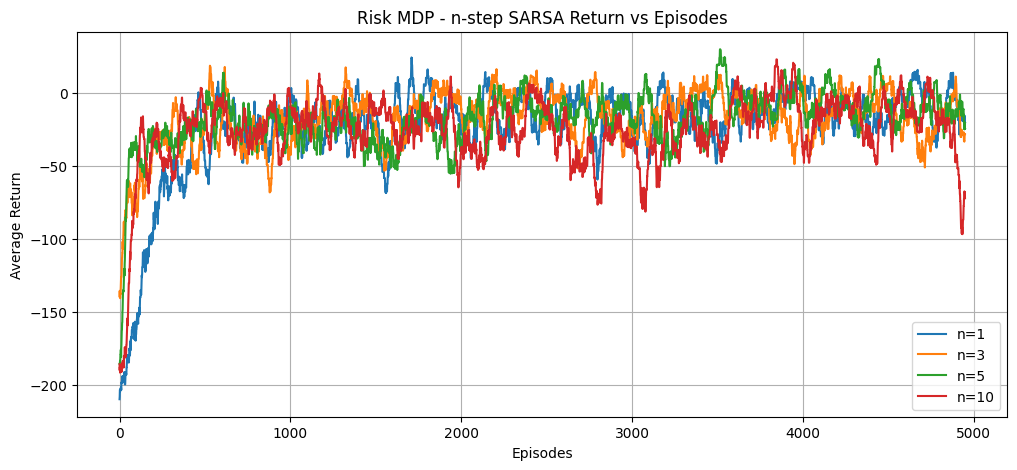

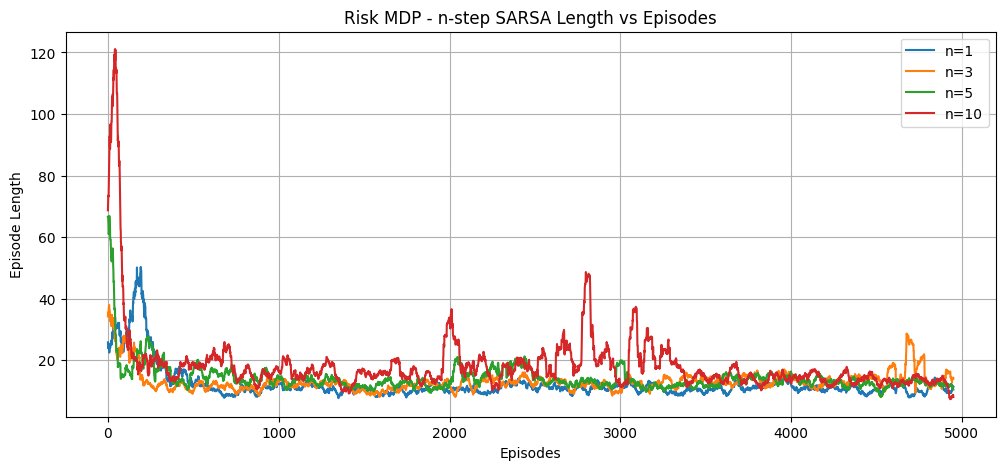

In [8]:
import matplotlib.pyplot as plt


def moving_avg(x, window=50):
    if len(x) < window:
        return x

    return np.convolve(x, np.ones(window) / window, mode='valid')


window = 50

plt.figure(figsize=(12, 5))
for n in sorted(results_r.keys()):
    plt.plot(moving_avg(results_r[n]["returns"], window), label=f"n={n}")

plt.xlabel("Episodes")
plt.ylabel("Average Return")
plt.title("Risk MDP - n-step SARSA Return vs Episodes")
plt.legend()
plt.grid()

plt.figure(figsize=(12, 5))
for n in sorted(results_r.keys()):
    plt.plot(moving_avg(results_r[n]["lengths"], window), label=f"n={n}")

plt.xlabel("Episodes")
plt.ylabel("Episode Length")
plt.title("Risk MDP - n-step SARSA Length vs Episodes")
plt.legend()
plt.grid()

plt.show()


## Q learning


In [9]:
def Q_to_V_risk(Q, states, terminal_states, ACTIONS):
    V_est = {}

    for s in states:
        if s in terminal_states:
            V_est[s] = 0.0
        else:
            V_est[s] = max(Q[(s, a)] for a in ACTIONS)

    return V_est



def run_q_learning_risk(states, terminal_states, ACTIONS, GAMMA, get_transitions,
                        V_optimal,
                        alpha_start=0.1,
                        epsilon_start=0.1,
                        epsilon_min=0.01,
                        episodes=5000,
                        max_steps=200):

    Q = {(s, a): 0.0 for s in states for a in ACTIONS if s not in terminal_states}

    returns = []
    lengths = []
    value_errors = []

    start_time = time.time()
    tracemalloc.start()

    non_terminal_states = [s for s in states if s not in terminal_states]

    alpha = alpha_start
    epsilon = epsilon_start

    for ep in range(episodes):
        state = random.choice(non_terminal_states)

        episode_return = 0
        episode_length = 0
        steps = 0

        while state not in terminal_states and steps < max_steps:
            if random.random() < epsilon:
                action = random.choice(ACTIONS)
            else:
                action = max(ACTIONS, key=lambda a: Q[(state, a)])

            next_state, reward = sample_transition(state, action)

            episode_return += reward
            episode_length += 1
            steps += 1

            if next_state in terminal_states:
                target = reward
            else:
                best_next = max(Q[(next_state, a)] for a in ACTIONS)
                target = reward + GAMMA * best_next

            Q[(state, action)] += alpha * (target - Q[(state, action)])
            state = next_state

        returns.append(episode_return)
        lengths.append(episode_length)

        epsilon = max(epsilon_min, epsilon_start * (0.995 ** ep))
        alpha = alpha_start / (1 + 0.001 * ep)

        V_est = Q_to_V_risk(Q, states, terminal_states, ACTIONS)
        err = np.mean([abs(V_est[s] - V_optimal[s]) for s in V_optimal])
        value_errors.append(err)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = time.time() - start_time

    policy = {}
    for s in states:
        if s in terminal_states:
            continue
        policy[s] = max(ACTIONS, key=lambda a: Q[(s, a)])

    return Q, policy, runtime, peak, returns, lengths, value_errors


Q_q_r, policy_q_r, time_q_r, mem_q_r, returns_q_r, lengths_q_r, value_errors_q_r = run_q_learning_risk(
    states,
    terminal_states,
    ACTIONS,
    GAMMA,
    get_transitions,
    V
)


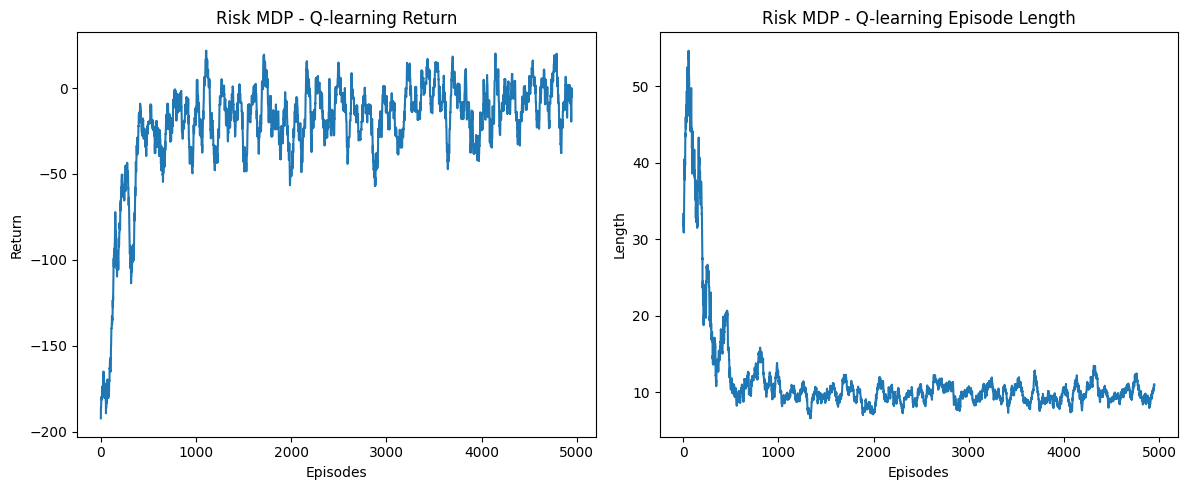

In [10]:
window = 50

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(moving_avg(returns_q_r, window))
plt.title("Risk MDP - Q-learning Return")
plt.xlabel("Episodes")
plt.ylabel("Return")

plt.subplot(1, 2, 2)
plt.plot(moving_avg(lengths_q_r, window))
plt.title("Risk MDP - Q-learning Episode Length")
plt.xlabel("Episodes")
plt.ylabel("Length")

plt.tight_layout()
plt.show()


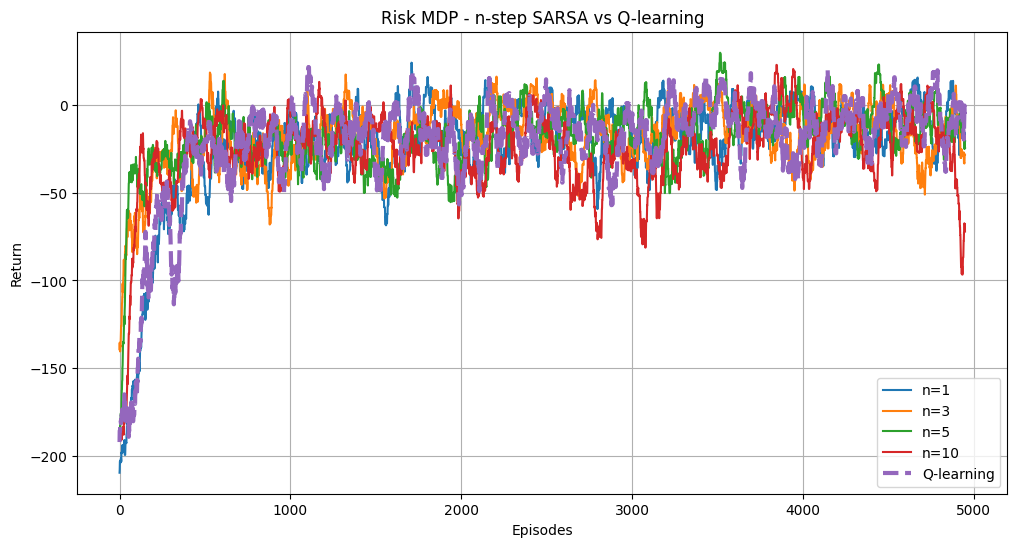

In [11]:
plt.figure(figsize=(12, 6))

for n in sorted(results_r.keys()):
    plt.plot(moving_avg(results_r[n]["returns"], window), label=f"n={n}")

plt.plot(moving_avg(returns_q_r, window), label="Q-learning", linewidth=3, linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Return")
plt.title("Risk MDP - n-step SARSA vs Q-learning")
plt.legend()
plt.grid()
plt.show()


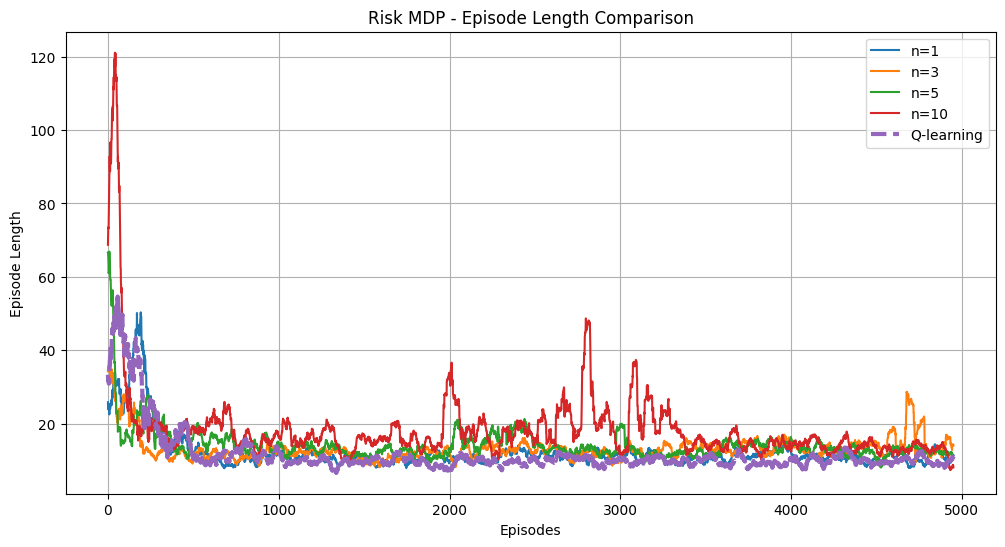

In [12]:
plt.figure(figsize=(12, 6))

for n in sorted(results_r.keys()):
    plt.plot(moving_avg(results_r[n]["lengths"], window), label=f"n={n}")

plt.plot(moving_avg(lengths_q_r, window), label="Q-learning", linewidth=3, linestyle='--')

plt.xlabel("Episodes")
plt.ylabel("Episode Length")
plt.title("Risk MDP - Episode Length Comparison")
plt.legend()
plt.grid()
plt.show()


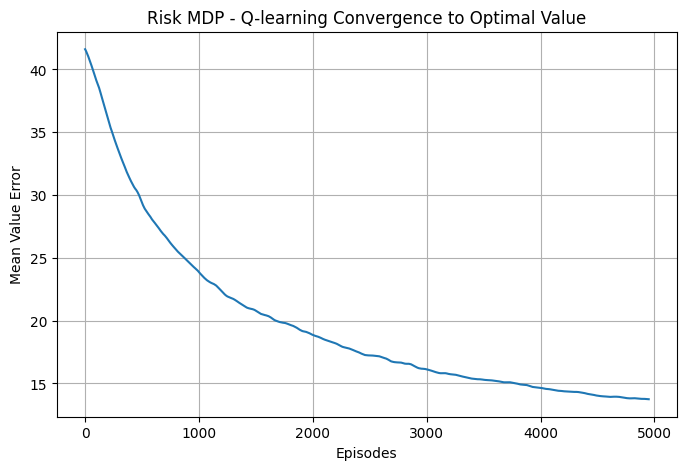

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(moving_avg(value_errors_q_r, window))
plt.xlabel("Episodes")
plt.ylabel("Mean Value Error")
plt.title("Risk MDP - Q-learning Convergence to Optimal Value")
plt.grid()
plt.show()


In [15]:
print("Final Performance Comparison")
print(f"{'Method':<20} {'Time (s)':<10} {'Memory (KB)':<12}")
print("-" * 45)
print(f"{'SARSA':<20} {time_sarsa_r:<10.4f} {mem_sarsa_r / 1024:<12.2f}")

for n in sorted(results_r.keys()):
    print(f"{f'n-step SARSA (n={n})':<20} {results_r[n]['time']:<10.4f} {results_r[n]['mem'] / 1024:<12.2f}")

print(f"{'Q-learning':<20} {time_q_r:<10.4f} {mem_q_r / 1024:<12.2f}")


Final Performance Comparison
Method               Time (s)   Memory (KB) 
---------------------------------------------
SARSA                6.3334     142.43      
n-step SARSA (n=1)   6.9046     148.14      
n-step SARSA (n=3)   7.2998     133.95      
n-step SARSA (n=5)   7.6869     129.83      
n-step SARSA (n=10)  10.4687    134.98      
Q-learning           8.7489     304.55      
